In [1]:
import torch
import os
import numpy as np
from scipy.ndimage import zoom
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches

from dflat.initialize import focusing_lens, multiplexing_mask_orthrand
from dflat.metasurface import reverse_lookup_optimize, load_optical_model
from dflat.plot_utilities import format_plot
from dflat.propagation import PointSpreadFunction
from dflat.render import hsi_to_rgb, general_convolve

from diffvis.data.ARAD import ARAD

out_name = "./gen2_psf4/"
if not os.path.exists(out_name):
    os.mkdir(out_name)

In [2]:
in_size = [501, 501]
in_dx_m=[4*250e-9, 4*250e-9]
out_distance = 10e-3

wavelength_set_m = np.array([420e-9, 520e-9, 580e-9, 660e-9])
dx = 210e-6
offsets = [[-dx, dx], [dx, dx], [dx, -dx], [-dx, -dx]]
depth_set_m = [10 for i in range(len(wavelength_set_m))]

amp, phase, aperture = focusing_lens(
    in_size,
    in_dx_m,
    wavelength_set_m,
    depth_set_m,
    offsets,
    out_distance,
    aperture_radius_m=None,
    radial_symmetry=False,
)
print(amp.shape, phase.shape)

(4, 501, 501) (4, 501, 501)


In [3]:
load_prev = True
if load_prev:
    with open(out_name + 'lens_lookup.pickle','rb') as handle:
        data = pickle.load(handle)
        shapes = data["shapes"]

else:
    list_shapes = []
    list_params = []
    for i in range(amp.shape[0]):
        param, shape, err = reverse_lookup_optimize(
            amp[i:i+1, None, None],
            phase[i:i+1,None, None],
            wavelength_set_m[i:i+1], 
            "Nanocylinders_TiO2_U250H600", 
            lr=5e-2, 
            max_iter=300, 
            opt_phase_only=False
        )
        list_shapes.append(shape)
        list_params.append(param)
        # zoom_factors = [1, 3, 3, 1]  # Do not scale the batch size or channels
        # shape = zoom(shape, zoom_factors, order=3)  # order=3 for bicubic
    
    shapes = np.concatenate(list_shapes, axis=0)
    params = np.concatenate(list_params, axis=0)

    data = {"shapes": shapes, "params": params}
    with open(out_name + 'lens_lookup.pickle', 'wb') as handle:
        pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)


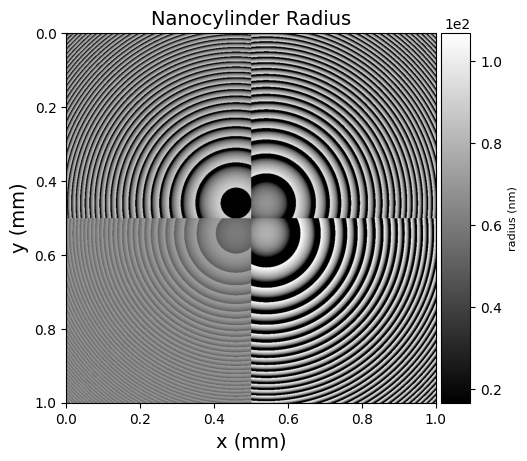

In [4]:
mixed_shapes1 = np.concatenate((shapes[1], shapes[0]), axis=0)
mixed_shapes2 = np.concatenate((shapes[2], shapes[3]), axis=0)

mixed_shapes = np.concatenate((mixed_shapes1, mixed_shapes2), axis=1).squeeze()
mixed_shapes = mixed_shapes[:1001, :1001]
xvec = np.arange(mixed_shapes.shape[0])*in_dx_m[0]*1e3
fig, ax = plt.subplots(1,1)
ax.imshow(mixed_shapes*1e9, cmap='gray')
format_plot(fig, ax, "x (mm)", "y (mm)", "Nanocylinder Radius", xvec=xvec, yvec=xvec, addcolorbar=True, setAspect="equal", cbartitle="radius (nm)", fs_text=14,fs_title=14, fs_ticks=10)

data = {"mixed_shapes": mixed_shapes, "shapes": shapes}
with open(out_name + 'grouped_lens.pickle', 'wb') as handle:
    pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [5]:
# ## Load the previously saved lens:
# with open("/home/deanhazineh/ssd2tb/diffvis_files/Lenses/gen2_lens/grouped_lens.pickle", 'rb') as handle:
#     data = pickle.load(handle)
#     mixed_shapes = data["mixed_shapes"]
#     shapes = data["shapes"]

In [5]:
#sim_wl = np.linspace(400e-9, 700e-9, 31)

sim_wl = np.linspace(450e-9, 650e-9, 28)
model = load_optical_model("Nanocylinders_TiO2_U250H600").to('cuda')
ampl, phase = model(mixed_shapes[None, :, :, None], sim_wl, pre_normalized=False)

Target Module: dflat.metasurface.optical_model.NeuralCells
Note: trainable_model key in NeuralCells is deprecated. Model will be set to requires_grad.
Target Module: dflat.metasurface.nn_siren.SirenNet
Target: dflat.metasurface.optical_model.NeuralCells Loading from checkpoint DFlat/Models/Nanocylinders_TiO2_U250H600/model.ckpt as strict=True
Restored dflat.metasurface.optical_model.NeuralCells with 0 missing and 0 unexpected keys


In [8]:
print(ampl.shape)
print(torch.amax(ampl[0,0], axis=(-1,-2)))

torch.Size([1, 1, 28, 1001, 1001])
tensor([0.9910, 0.9961, 0.9952, 0.9954, 0.9995, 0.9974, 0.9940, 0.9932, 0.9904,
        0.9882, 0.9864, 0.9884, 0.9902, 0.9903, 0.9907, 0.9928, 0.9943, 0.9947,
        0.9958, 0.9959, 0.9955, 0.9977, 1.0009, 1.0013, 0.9992, 1.0007, 1.0060,
        1.0110], device='cuda:0', grad_fn=<AmaxBackward0>)


In [25]:
out_dx_m = [5e-6, 5e-6]
ps_locs = [[0.0, 0.0, 10]]
in_size = [1001, 1001]

PSF = PointSpreadFunction(
    in_size, 
    in_dx_m, 
    out_distance, 
    [128, 128], 
    out_dx_m,
    sim_wl,
    diffraction_engine='fresnel')
psfi, psfp = PSF(ampl, phase, ps_locs)
psf_int = psfi.detach().cpu().numpy().squeeze()
psf_phase = psfp.detach().cpu().numpy().squeeze()
psf_rgb = hsi_to_rgb(psf_int[None], sim_wl, demosaic=False, tensor_ordering=True).squeeze()
psf_gs = np.sum(psf_int, axis=0)


In [26]:
print(psfi.shape)
print( torch.sum(psfi[0,0,0], axis=(-1,-2)) )


torch.Size([1, 1, 1, 28, 128, 128])
tensor([0.4612, 0.4785, 0.5255, 0.5566, 0.5854, 0.6036, 0.6355, 0.6268, 0.6357,
        0.6466, 0.6591, 0.6656, 0.6693, 0.6736, 0.6634, 0.6581, 0.6327, 0.6170,
        0.6330, 0.5967, 0.6212, 0.5964, 0.5941, 0.5989, 0.5723, 0.5700, 0.5383,
        0.5521], device='cuda:0', grad_fn=<SumBackward1>)


In [10]:
out_name = "./gen2_psf4/CASSI_Matched_"

In [11]:
def vis_psf(psf_int, sim_wl, fname):
    psf_rgb = hsi_to_rgb(psf_int[None], sim_wl, demosaic=False, tensor_ordering=True)
    psf_gs = np.sum(psf_int,axis=0)
    #xax = np.arange(out_size[0])*out_dx_m[0]*1e6

    fig = plt.figure(figsize=(6, 9))
    gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1])
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    ax2 = fig.add_subplot(gs[2, 0])
    ax3 = fig.add_subplot(gs[2, 1])

    ax1.imshow(np.transpose(psf_rgb[0], [1,2,0]))
    format_plot(fig, ax1, xlabel="x ($\mu m$)", ylabel="y ($\mu m$)", title="PSF (RGB)", fs_text=14,fs_title=14, fs_ticks=10 )
    #format_plot(fig, ax1, xvec=xax, yvec=xax, xlabel="x ($\mu m$)", ylabel="y ($\mu m$)", title="PSF (RGB)", fs_text=14,fs_title=14, fs_ticks=10 )

    ax2.imshow(psf_gs, cmap='gray')
    format_plot(fig, ax2, title="PSF (gray)", fs_text=14,fs_title=14, fs_ticks=10 )
    #format_plot(fig, ax2, xvec=xax, yvec=xax, title="PSF (gray)", fs_text=14,fs_title=14, fs_ticks=10 )

    ax3.imshow(np.log10(psf_gs), cmap='gray')
    format_plot(fig, ax3, title="Log10(PSF) (gray)", fs_text=14,fs_title=14, fs_ticks=10 )
    #format_plot(fig, ax3, xvec=xax, yvec=xax, title="Log10(PSF) (gray)", fs_text=14,fs_title=14, fs_ticks=10 )

    plt.tight_layout()
    plt.savefig(out_name+fname+".png")
    plt.close()

    return

out_dx_m = [5e-6, 5e-6]
ps_locs = [[0.0, 0.0, 10]]
in_size = [1001, 1001]

PSF = PointSpreadFunction(
    in_size, 
    in_dx_m, 
    out_distance, 
    [64, 64], 
    out_dx_m,
    sim_wl,
    diffraction_engine='fresnel')
psfi, psfp = PSF(ampl, phase, ps_locs)
psf_int = psfi.detach().cpu().numpy().squeeze()
psf_phase = psfp.detach().cpu().numpy().squeeze()
psf_rgb = hsi_to_rgb(psf_int[None], sim_wl, demosaic=False, tensor_ordering=True).squeeze()
psf_gs = np.sum(psf_int, axis=0)

name = "psf4_compact64"
vis_psf(psf_int, sim_wl, name)
data = {"psf_int": psf_int, "wl": sim_wl, "psf_rgb": psf_rgb, "psf_gs": psf_gs}
with open(out_name + name + '.pickle', 'wb') as handle:
   pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)

###
PSF = PointSpreadFunction(
    in_size, 
    in_dx_m, 
    out_distance, 
    [32, 32], 
    out_dx_m,
    sim_wl,
    diffraction_engine='fresnel')
psfi, psfp = PSF(ampl, phase, ps_locs)
psf_int = psfi.detach().cpu().numpy().squeeze()
psf_phase = psfp.detach().cpu().numpy().squeeze()
psf_rgb = hsi_to_rgb(psf_int[None], sim_wl, demosaic=False, tensor_ordering=True).squeeze()
psf_gs = np.sum(psf_int, axis=0)

name = "psf4_compact32"
vis_psf(psf_int, sim_wl, name)
data = {"psf_int": psf_int, "wl": sim_wl, "psf_rgb": psf_rgb, "psf_gs": psf_gs}
with open(out_name + name + '.pickle', 'wb') as handle:
   pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [7]:
hsi_data = ARAD(
    root_dir="/home/deanhazineh/ssdnvme/ARAD1k_Dataset/Arad1k/",
    mode="train",
    num_dat=10,
    num_ch=31,
)
psf_int = psf_int / np.max(psf_int)

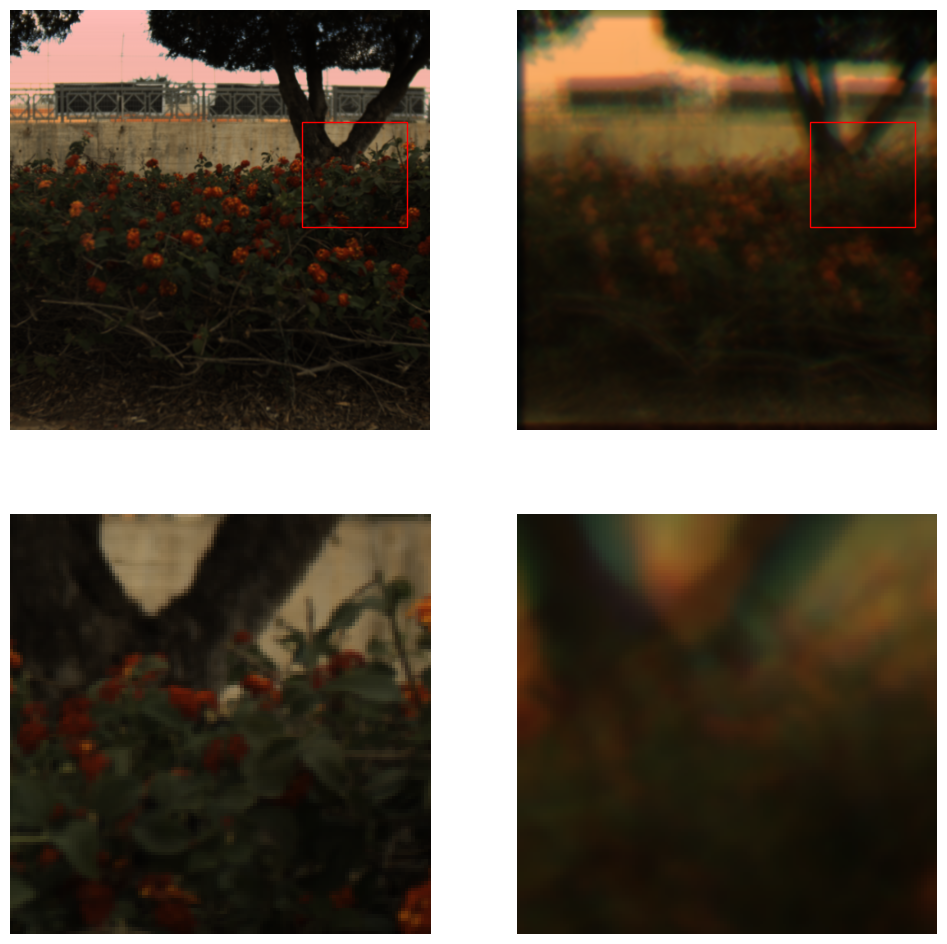

In [8]:
def get_zoomed_in_region(image, center, width):
    x, y = center
    return image[:, y - width // 2:y + width // 2, x - width // 2:x + width // 2]

idx = 8
cube = hsi_data[idx]
rgb = hsi_to_rgb(cube[None], sim_wl, gamma=False, demosaic=False, tensor_ordering=True)

mhsi = general_convolve(torch.tensor(cube, dtype=torch.float32, device='cuda'), torch.tensor(psf_int, dtype=torch.float32, device='cuda'), rfft=True).cpu().numpy()
mrgb = hsi_to_rgb(mhsi[None], sim_wl, gamma=False, demosaic=False, tensor_ordering=True)

zoom_width = 128 
center = (420, 200)  

fig, ax = plt.subplots(2,2, figsize=(12,12))
ax[0,0].imshow(np.transpose(rgb[0],[1,2,0]))
ax[0,1].imshow(np.transpose(mrgb[0], [1,2,0]))
ax[0, 0].add_patch(patches.Rectangle((center[0] - zoom_width // 2, center[1] - zoom_width // 2), zoom_width, zoom_width, linewidth=1, edgecolor='r', facecolor='none'))
ax[0, 1].add_patch(patches.Rectangle((center[0] - zoom_width // 2, center[1] - zoom_width // 2), zoom_width, zoom_width, linewidth=1, edgecolor='r', facecolor='none'))

zoomed_rgb = get_zoomed_in_region(rgb[0], center, zoom_width)
zoomed_mrgb = get_zoomed_in_region(mrgb[0], center, zoom_width)

ax[1, 0].imshow(np.transpose(zoomed_rgb, [1, 2, 0]))
ax[1, 1].imshow(np.transpose(zoomed_mrgb, [1, 2, 0]))

for axi in ax.flatten():
    axi.axis('off')
plt.savefig(out_name+f"rendered_{idx}.png")